In [66]:
'''
Project Description -
1.Worked with an Instructor Effectiveness dataset containing 2,000 records across different instructors, courses, and batches.
2.Analyzed key learning metrics such as:
  * Student completion rate
  * Dropout rate
  * Average watch time
  * Assignment submission rate
  * Forum participation
  * Average quiz scores
  * Score improvement
  * Feedback response rate
  * Average instructor feedback score
3. Performed data preprocessing - by handling missing values, removing duplicates.
4. Conducted feature engineering to identify the factors that most influence instructor effectiveness and student engagement and made new features our of old ones.
5.Built a machine learning regression model to predict metrics like average feedback score or student completion rate.
6. Evaluated the model using regression metrics such as MAE, RMSE, and R2 Score.
7. The insights helped identify at-risk course batches and highlighted areas where instructors could improve student engagement.
8 The project demonstrated how data-driven insights can support better teaching strategies, improve course quality, and enhance overall student satisfaction.
'''


'\nProject Description - \n1.Worked with an Instructor Effectiveness dataset containing 2,000 records across different instructors, courses, and batches.\n2.Analyzed key learning metrics such as:\n  * Student completion rate\n  * Dropout rate\n  * Average watch time\n  * Assignment submission rate\n  * Forum participation\n  * Average quiz scores\n  * Score improvement\n  * Feedback response rate\n  * Average instructor feedback score\n3. Performed data preprocessing - by handling missing values, removing duplicates.\n4. Conducted feature engineering to identify the factors that most influence instructor effectiveness and student engagement and made new features our of old ones.\n5.Built a machine learning regression model to predict metrics like average feedback score or student completion rate.\n6. Evaluated the model using regression metrics such as MAE, RMSE, and R2 Score.\n7. The insights helped identify at-risk course batches and highlighted areas where instructors could improve 

In [67]:
import numpy as np
import pandas as pd
df = pd.read_csv('/content/dataset.csv')
display(df.head())


,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


In [69]:
df.shape

(2000, 12)

In [70]:
df.isnull().sum()

,0
batch_id,0
instructor_id,0
course_id,0
completion_rate,0
avg_score_improvement,0
avg_quiz_score,0
dropout_rate,0
avg_watch_time,0
assignment_submission_rate,0
forum_activity_rate,0


In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


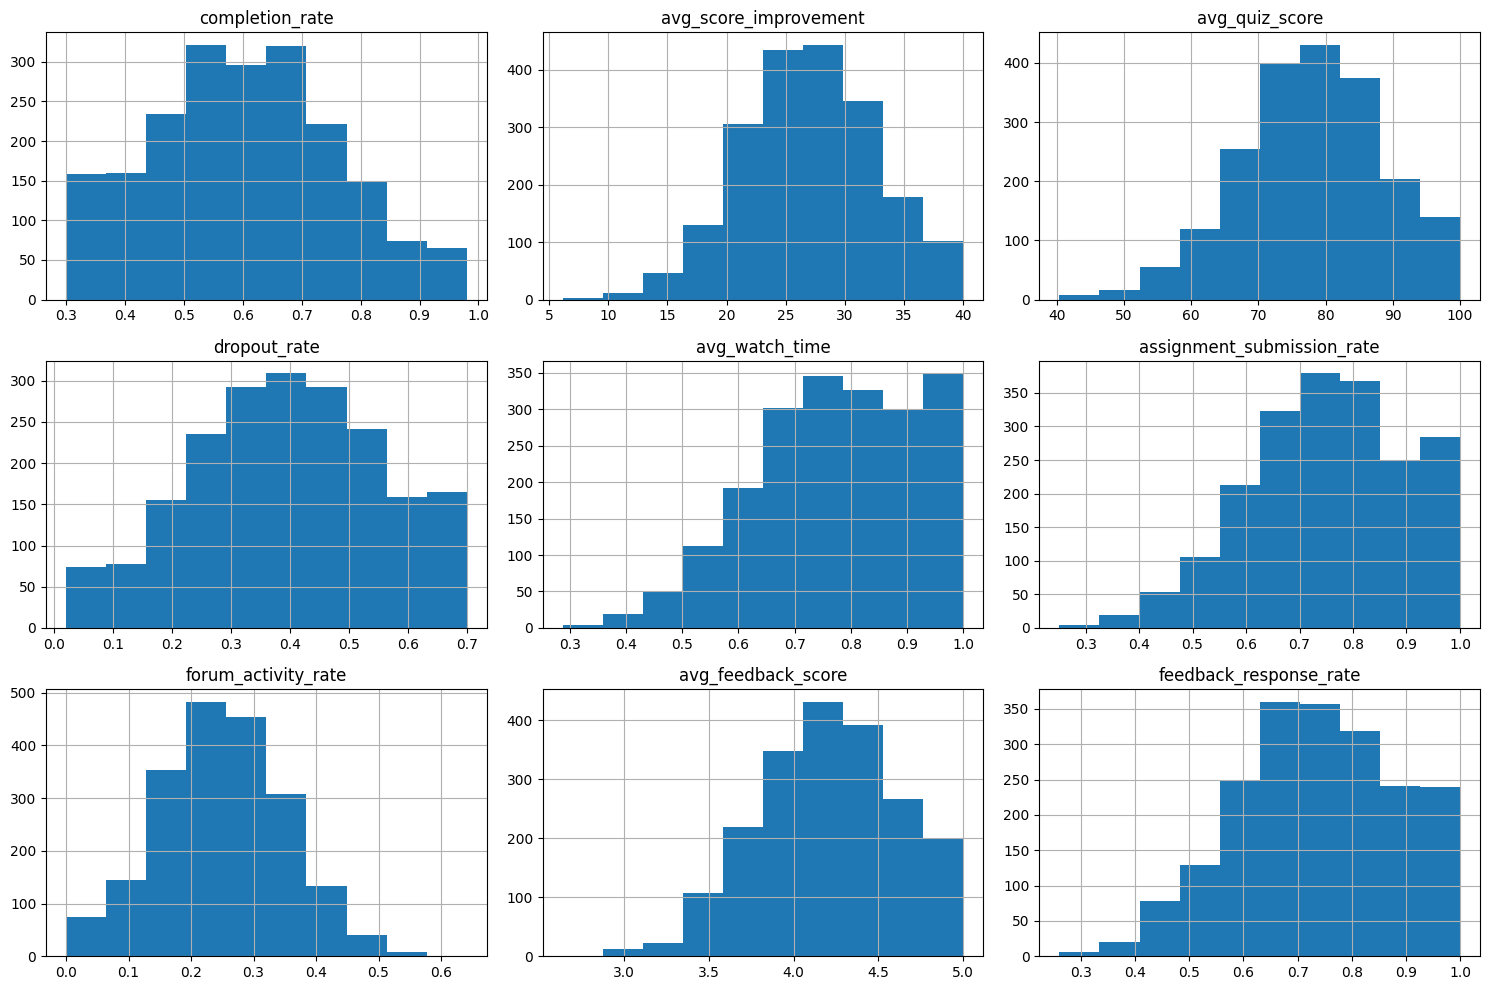

' analysis -the numerical features show mostly well-behaved distributions with no severe anomalies.\nStudent engagement metrics such as watch time, assignment submission rate, and feedback response rate are concentrated toward higher values, indicating generally active participation. \nQuiz scores and feedback scores are also centered around strong performance ranges, while dropout rate shows moderate variability across batches.'

In [73]:
import matplotlib.pyplot as plt
df.hist(figsize=(15,10))
plt.tight_layout()
plt.show()

''' analysis -the numerical features show mostly well-behaved distributions with no severe anomalies.
Student engagement metrics such as watch time, assignment submission rate, and feedback response rate are concentrated toward higher values, indicating generally active participation.
Quiz scores and feedback scores are also centered around strong performance ranges, while dropout rate shows moderate variability across batches.'''


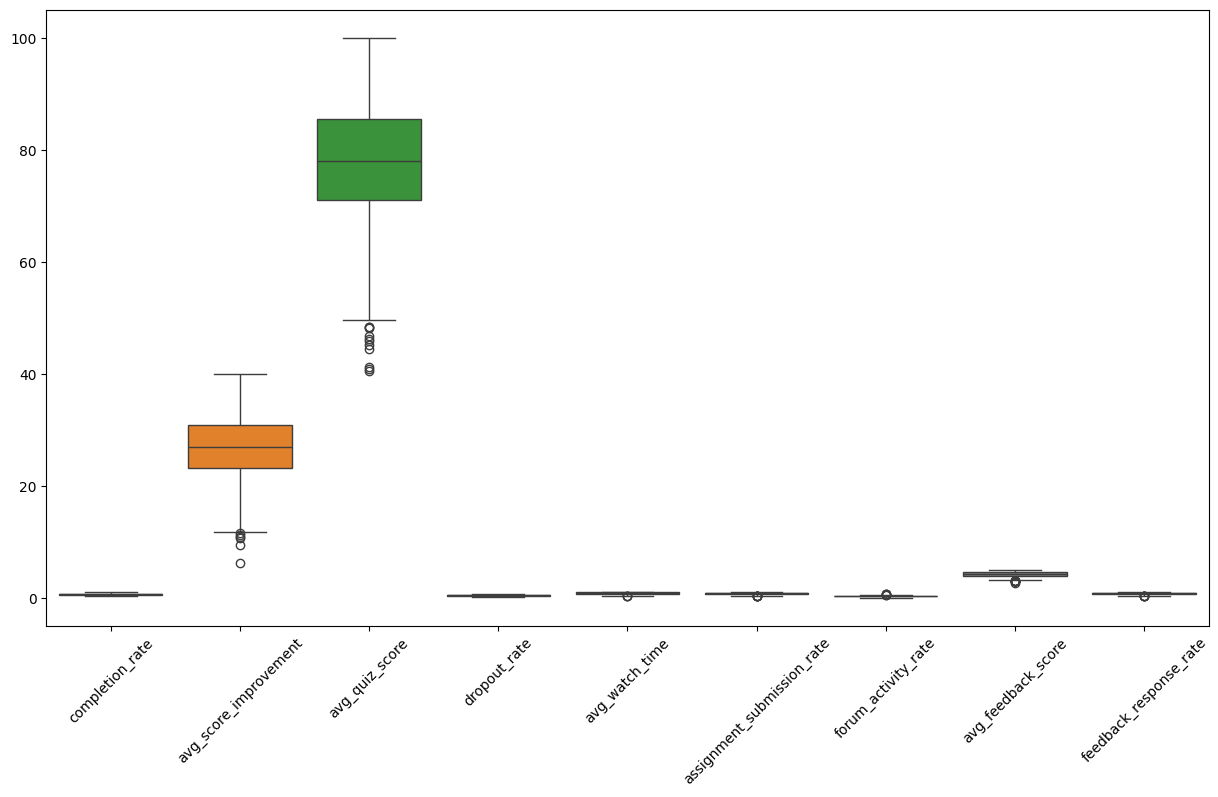

' Analysis-Boxplots indicate a small number of outliers across several numerical features. \nThese values appear to represent natural variation in instructor and student performance rather than data entry errors'

In [74]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(15,8))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.show()

''' Analysis-Boxplots indicate a small number of outliers across several numerical features.
These values appear to represent natural variation in instructor and student performance rather than data entry errors'''

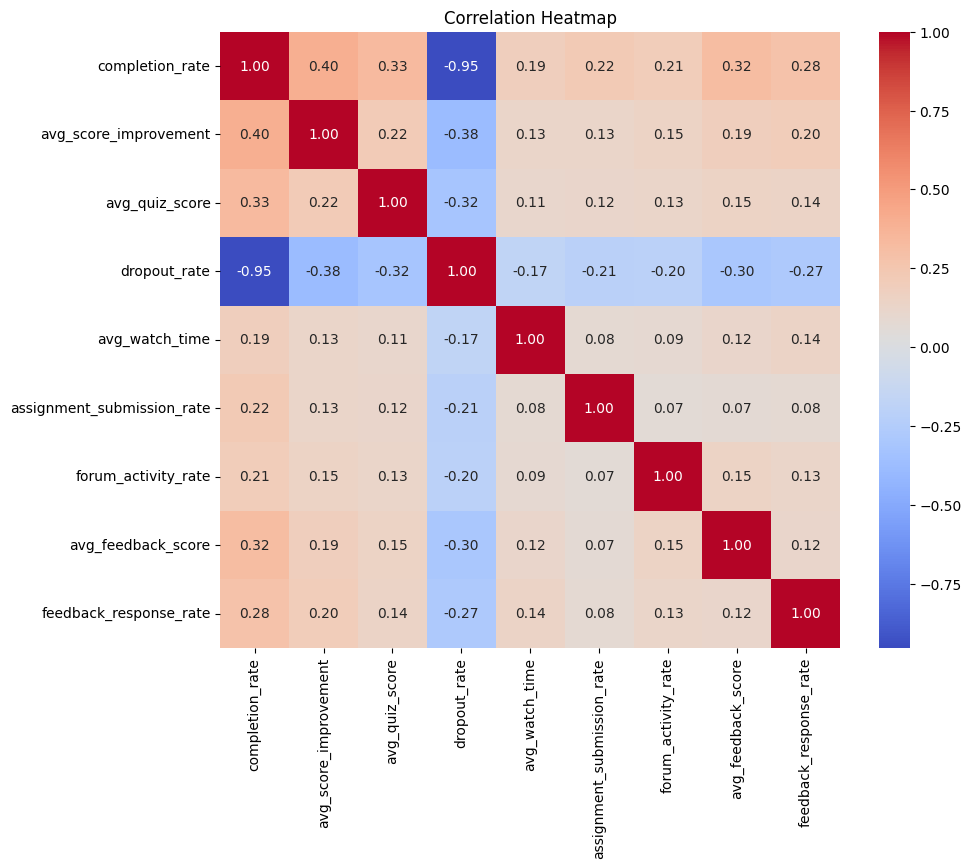

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title("Correlation Heatmap")
plt.show()

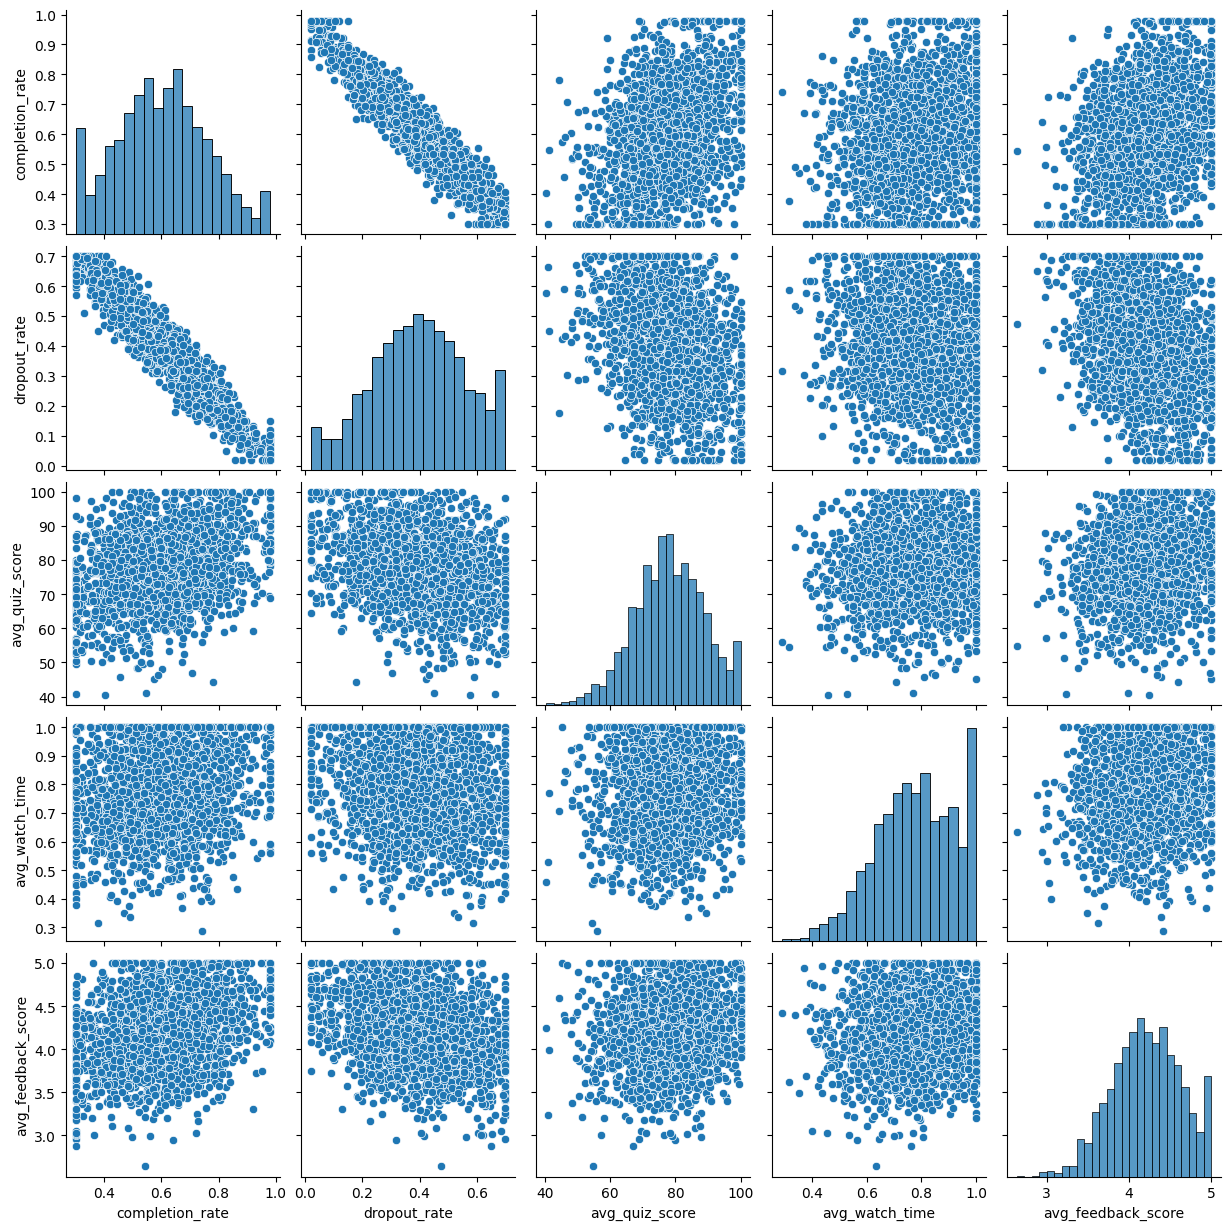

In [76]:
#bivariate analysis
sns.pairplot(
    df[
        [
            'completion_rate',
            'dropout_rate',
            'avg_quiz_score',
            'avg_watch_time',
            'avg_feedback_score'
        ]
    ]
)

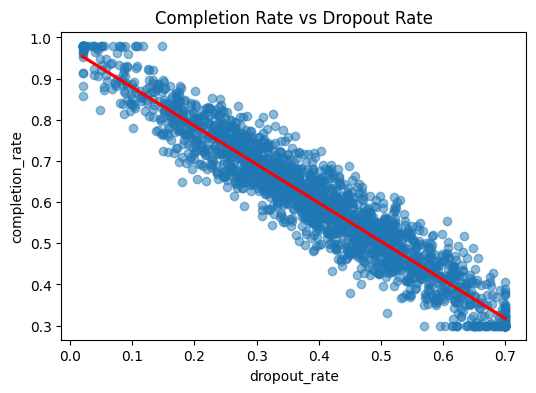

In [23]:
plt.figure(figsize=(6,4))
sns.regplot(
    x='dropout_rate',
    y='completion_rate',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title('Completion Rate vs Dropout Rate')
plt.show()

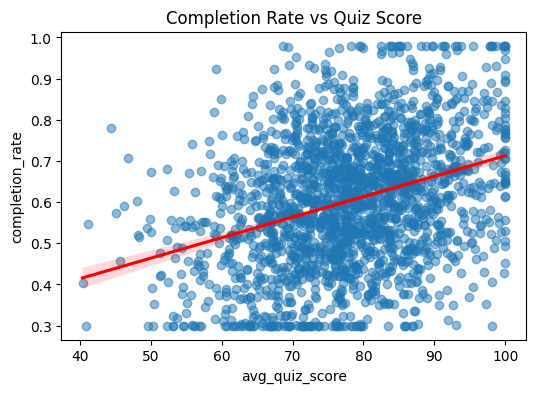

In [29]:
plt.figure(figsize=(6,4))
sns.regplot(
    x='avg_quiz_score',
    y='completion_rate',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)
plt.title('Completion Rate vs Quiz Score')
plt.show()

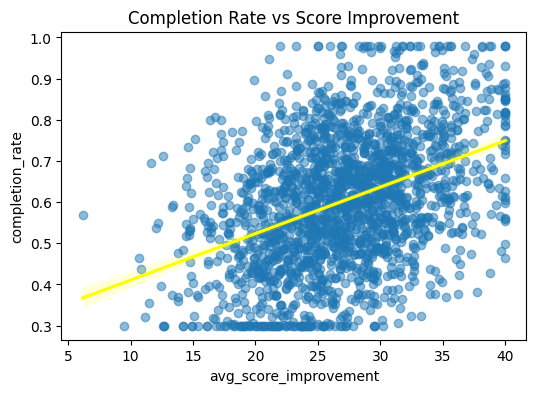

In [27]:
plt.figure(figsize=(6,4))
sns.regplot(
    x='avg_score_improvement',
    y='completion_rate',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'yellow'}
)
plt.title('Completion Rate vs Score Improvement')
plt.show()

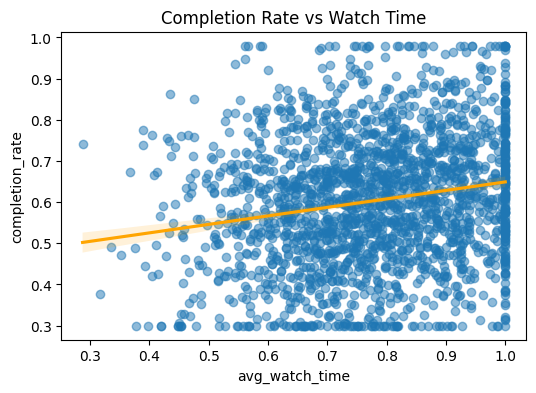

In [32]:
plt.figure(figsize=(6,4))
sns.regplot(
    x='avg_watch_time',
    y='completion_rate',
    data=df,
    scatter_kws={'alpha':0.5},
    line_kws={'color':'orange'}
)
plt.title('Completion Rate vs Watch Time')
plt.show()

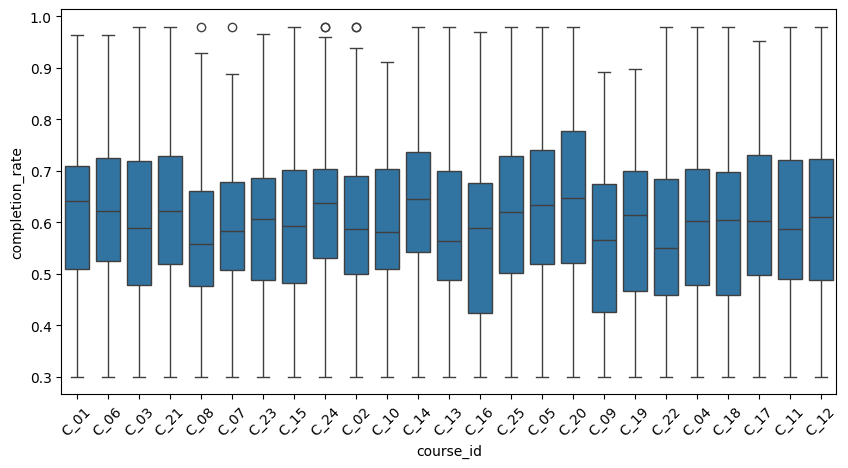

In [33]:
plt.figure(figsize=(10,5))
sns.boxplot(
    x='course_id',
    y='completion_rate',
    data=df
)
plt.xticks(rotation=45)
plt.show()

<Axes: xlabel='course_id'>

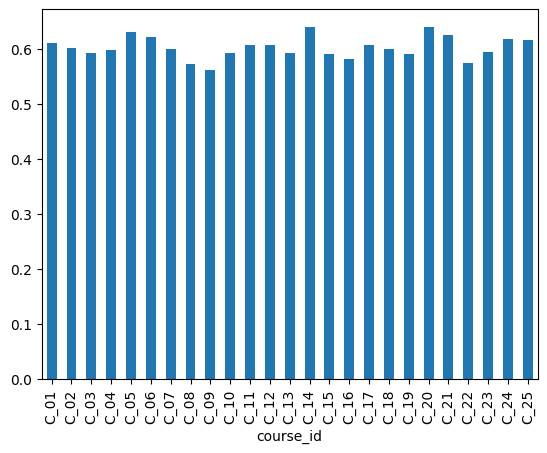

In [34]:
df.groupby('course_id')['completion_rate'].mean().plot(kind='bar')

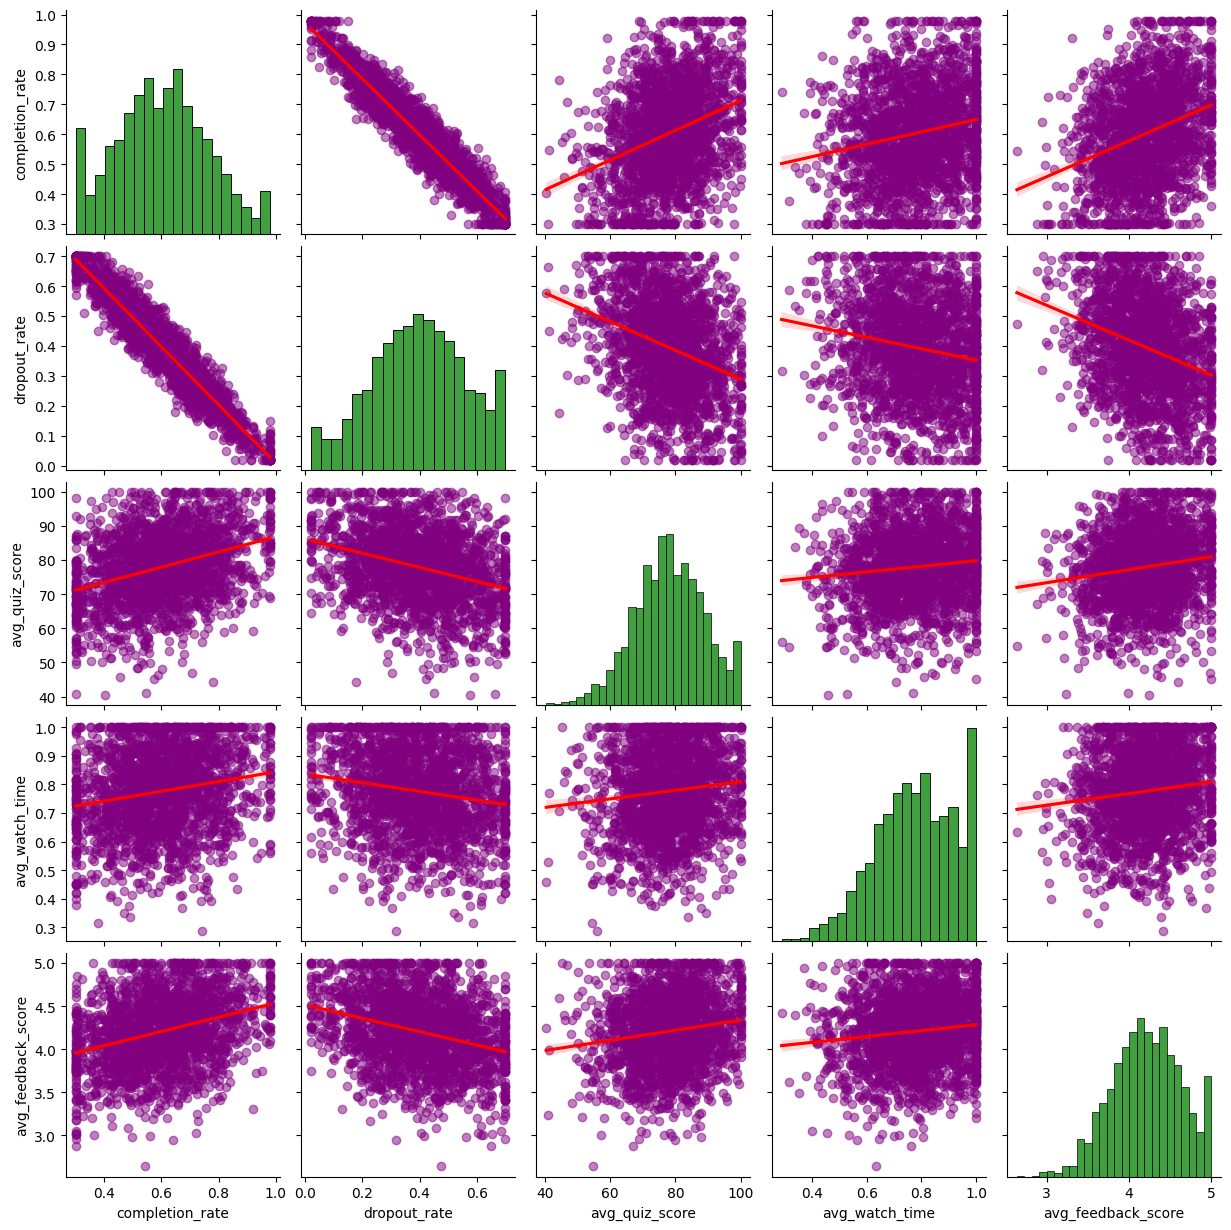

In [77]:
sns.pairplot(
    df[
        [
            'completion_rate',
            'dropout_rate',
            'avg_quiz_score',
            'avg_watch_time',
            'avg_feedback_score'
        ]
    ],
    kind='reg',
    plot_kws={
        'scatter_kws': {'color':'purple', 'alpha':0.5},
        'line_kws': {'color':'red'}
    },
    diag_kws={'color':'green'}
)

plt.show()

In [78]:
df['engagement_score'] = (
    df['avg_watch_time'] +
    df['assignment_submission_rate'] +
    df['forum_activity_rate']
) / 3

df['learning_performance'] = (
    df['avg_quiz_score'] +
    df['avg_score_improvement']
) / 2

In [80]:
# student completion rate pipeline
target = 'completion_rate'
features = [
    'dropout_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate',
    'engagement_score',
    'learning_performance'
]
X = df[features]
y = df[target]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [81]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [82]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 0.0366789244721473
RMSE: 0.04505578509249761
R² Score: 0.9263319848992809


In [83]:
#AVG feedback score calculation
features = [
    'completion_rate',
    'dropout_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'feedback_response_rate',
    'engagement_score',
    'learning_performance'
]
X = df[features]
y = df['avg_feedback_score']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lr_feedback = LinearRegression()
lr_feedback.fit(X_train, y_train)
y_pred = lr_feedback.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Linear Regression Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)

Linear Regression Results
MAE : 0.3369831731236722
RMSE: 0.4077264399272933
R² Score: 0.09508860042715117


In [84]:
#dropout rate calculation

features = [
    'completion_rate',
    'avg_score_improvement',
    'avg_quiz_score',
    'avg_watch_time',
    'assignment_submission_rate',
    'forum_activity_rate',
    'avg_feedback_score',
    'feedback_response_rate',
    'engagement_score',
    'learning_performance'
]

X = df[features]
y = df['dropout_rate']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
lr_dropout = LinearRegression()
lr_dropout.fit(X_train, y_train)
y_pred = lr_dropout.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Linear Regression Results")
print("MAE :", mae)
print("RMSE:", rmse)
print("R² Score:", r2)


Linear Regression Results
MAE : 0.03655991347518448
RMSE: 0.045833043956922996
R² Score: 0.9244861109966879
